In [2]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import imageio
import pydicom
import SimpleITK as sitk

In [16]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_nib(file_path: str):
    nii_data = nib.load(file_path)

    image_data = nii_data.get_fdata()
    return image_data

def save_nib(file_path: str, volume):
    ct_image = sitk.GetImageFromArray(volume)
    sitk.WriteImage(ct_image, file_path)

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

def lung_window_clip(array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = array.copy()
    clipped_array[clipped_array > max_px] = max_px
    clipped_array[clipped_array < min_px] = min_px
    return clipped_array

def plot_images(array_HU, array_Lung, title1="HU", title2="Lung"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(array_HU, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis("off")  # Hide axis

    axes[1].imshow(array_Lung, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis("off")  # Hide axis


In [ ]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/images/LIDC-IDRI-0210.npy"
pixel_array = load_npy(file_path)
print("Volume shape:", pixel_array.shape)
print("Max pixel:", pixel_array.max())
print("Min pixel:", pixel_array.min())

Volume shape: (128, 256, 256)
Max pixel: 2047.0
Min pixel: -3072.0


297.0
-3072.0


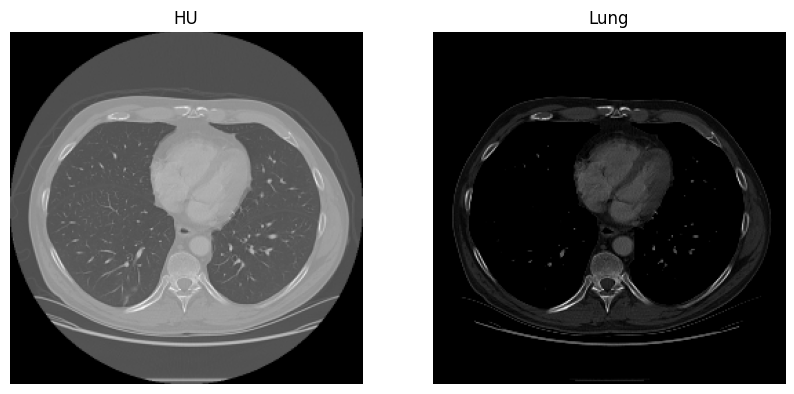

In [70]:
array_HU = pixel_array[50, :, :]
print(array_HU.max())
print(array_HU.min())
array_Lung = normalize_image(lung_window_clip(array_HU))

plot_images(array_HU, array_Lung)

Max pixel: 1283.0
Min pixel: -2048.0
Max pixel: 1283
Min pixel: -2048
Max pixel: 2307
Min pixel: -1024


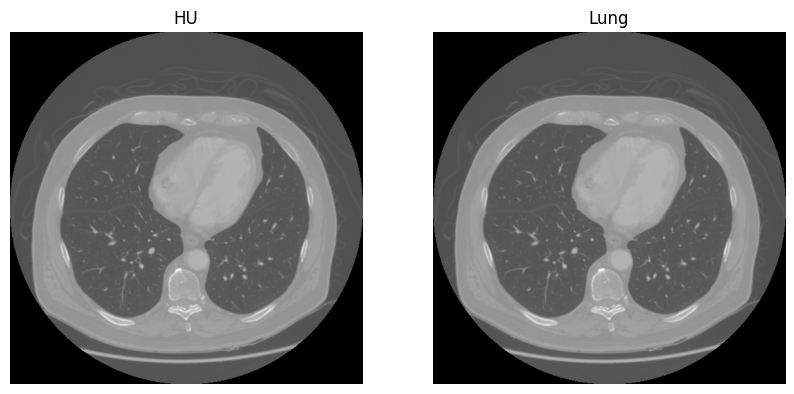

In [66]:
dicom = load_dcom('/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0210/01-01-2000-NA-POST CHEST-29270/2.000000-CHEST-99234/1-078.dcm')

arr_dcom = dicom.pixel_array * dicom.RescaleSlope + dicom.RescaleIntercept
print("Max pixel:", arr_dcom.max())
print("Min pixel:", arr_dcom.min())

# arr_dcom_lung = normalize_image(lung_window_clip(arr_dcom))
print("Max pixel:", pixel_array[:, :, 50].max())
print("Min pixel:", pixel_array[:, :, 50].min())

print("Max pixel:", dicom.pixel_array.max())
print("Min pixel:", dicom.pixel_array.min())

plot_images(pixel_array[:, :, 50], dicom.pixel_array)

In [62]:
test = pixel_array[:, :, 50] + 1024 - dicom.pixel_array
print(test.sum())

2051600


In [23]:
print(arr_dcom.max())
print(arr_dcom.min())

3071.0
-2048.0


In [30]:
print(dicom.pixel_array.max())
print(dicom.pixel_array.min())

4095
-1024


In [28]:

print(pixel_array.max())
print(pixel_array.min())

2047.0
-3072.0


In [33]:
files

[]